# Telco Customer Churn — end-to-end analysis

**Question:** which customers are about to leave, and which of them are worth calling?

Those are two different questions and only the first one is a model. The second
needs a probability *cutoff* chosen against the cost of being wrong, which is
where most churn notebooks stop early — they report an AUC and leave the model
predicting at 0.5.

This notebook goes from the raw IBM Telco file to a saved pipeline the API
serves, in the order I actually worked:

1. Load the data and see what is wrong with it
2. Clean it, deliberately, writing down each decision
3. Split **before** fitting anything
4. Explore the training half only
5. Engineer features that encode something I believe about churn
6. Compare three model families honestly
7. Pick the champion on validation, tune the threshold on validation
8. Open the test set **once**
9. Explain the model, then save what serving needs

Two custom transformers (`FeatureEngineer`, `BinaryEncoder`) are imported from
`pipeline_lib.py` rather than defined here. That is not architecture for its own
sake: a pickled pipeline stores its steps by import path, so a class defined in
a notebook pickles as `__main__.FeatureEngineer` and the API can never load it.
Everything else lives in this notebook.

In [1]:
import json
import datetime
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, confusion_matrix,
    classification_report,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif

import xgboost as xgb
import lightgbm as lgb

import sys
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
import pipeline_lib as lib
from pipeline_lib import FeatureEngineer, BinaryEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = lib.RANDOM_STATE
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

print(f"pandas {pd.__version__} | xgboost {xgb.__version__} | lightgbm {lgb.__version__}")

pandas 2.2.3 | xgboost 2.1.3 | lightgbm 4.5.0


## 1. Load the data

7,043 customers from IBM's public Telco churn set. It downloads once and caches
locally, so this notebook runs from a clean checkout with no credentials.

In [2]:
if not lib.RAW_DATA_FILE.exists():
    print("downloading...")
    pd.read_csv(lib.DATASET_URL).to_csv(lib.RAW_DATA_FILE, index=False)

raw = pd.read_csv(lib.RAW_DATA_FILE)
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(3)

7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# What am I actually working with?
info = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "n_missing": raw.isna().sum(),
    "sample": [raw[c].dropna().iloc[0] if raw[c].notna().any() else None for c in raw.columns],
})
info

,dtype,n_unique,n_missing,sample
customerID,object,7043,0,7590-VHVEG
gender,object,2,0,Female
SeniorCitizen,int64,2,0,0
Partner,object,2,0,Yes
Dependents,object,2,0,No
tenure,int64,73,0,1
PhoneService,object,2,0,No
MultipleLines,object,3,0,No phone service
InternetService,object,3,0,DSL
OnlineSecurity,object,3,0,No


### First look — three things stand out

**`TotalCharges` is stored as text.** It should be numeric. Something in that
column is not a number.

**No nulls anywhere**, which for a real dataset is suspicious rather than
reassuring — it usually means missingness is encoded as something else.

**`customerID` is unique per row**, so it is an identifier, not a feature. It
has to go before modeling, but *after* de-duplication.

In [4]:
# Chase down the TotalCharges dtype
coerced = pd.to_numeric(raw["TotalCharges"], errors="coerce")
bad = raw.loc[coerced.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]
print(f"{len(bad)} rows where TotalCharges will not parse")
print(f"tenure values among them: {sorted(bad['tenure'].unique())}")
bad.head()

11 rows where TotalCharges will not parse
tenure values among them: [0]


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,


There it is: 11 customers with a literal space `" "` in `TotalCharges`, and every
one of them has `tenure = 0`. These are customers who signed up and have not
been billed yet. Their total charges are genuinely zero, not missing — so
imputing 0 is the honest fix, not a median.

This is exactly the missingness the "no nulls" check hid.

In [5]:
print(f"duplicate customerIDs: {raw['customerID'].duplicated().sum()}")
print(f"fully duplicated rows:  {raw.duplicated().sum()}")
churn_rate = (raw["Churn"] == "Yes").mean()
print(f"\nchurn rate: {churn_rate:.1%}  ({(raw['Churn'] == 'Yes').sum():,} of {len(raw):,})")

duplicate customerIDs: 0
fully duplicated rows:  0

churn rate: 26.5%  (1,869 of 7,043)


## 2. Cleaning

Four decisions, each written down:

1. **De-duplicate on `customerID`, then drop it.** Order matters. If I dropped
   the ID first and de-duplicated on all remaining columns, two genuinely
   different customers with identical profiles would collapse into one.
2. **`TotalCharges` → numeric, blanks → 0.** Justified above.
3. **Target → 0/1** so sklearn can use it.
4. **Nothing else.** No outlier removal, no scaling here — scaling belongs
   inside the pipeline so it can be fit on training folds only.

In [6]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if lib.ID_COLUMN in df.columns:
        before = len(df)
        df = df.drop_duplicates(subset=[lib.ID_COLUMN])
        if before - len(df):
            print(f"dropped {before - len(df)} duplicate customer IDs")
        df = df.drop(columns=[lib.ID_COLUMN])
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)
    if df[lib.TARGET].dtype == object:
        df[lib.TARGET] = df[lib.TARGET].map({"Yes": 1, "No": 0})
    return df

df = clean(raw)
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns after cleaning")
print(f"TotalCharges dtype is now {df['TotalCharges'].dtype}")

7,043 rows x 20 columns after cleaning
TotalCharges dtype is now float64


## 3. Split first, explore second

The split happens now, before any exploration or fitting. If I explore the whole
dataset and let what I see shape my feature choices, the test set has already
leaked into the model through me.

70 / 15 / 15, stratified so all three sets carry the same churn rate. Validation
is what I am allowed to look at repeatedly; test gets opened once at the end.

In [7]:
X = df.drop(columns=[lib.TARGET])
y = df[lib.TARGET]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_STATE
)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5} n={len(yy):5,}  ({len(yy)/len(y):4.1%} of data)  churn={yy.mean():.3f}")

train n=4,932  (70.0% of data)  churn=0.265
val   n=1,054  (15.0% of data)  churn=0.266
test  n=1,057  (15.0% of data)  churn=0.265


## 4. Exploring the training set

Everything below uses `X_train` / `y_train` only.

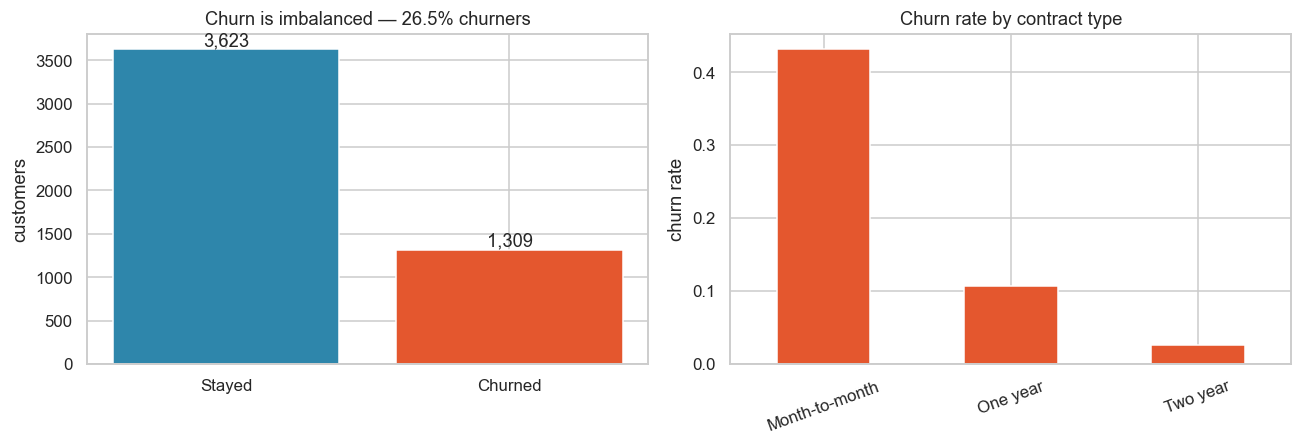

In [8]:
train = X_train.copy()
train[lib.TARGET] = y_train

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

counts = train[lib.TARGET].value_counts().sort_index()
axes[0].bar(["Stayed", "Churned"], counts.values, color=["#2E86AB", "#E4572E"])
axes[0].set_title(f"Churn is imbalanced — {train[lib.TARGET].mean():.1%} churners")
axes[0].set_ylabel("customers")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

ct = pd.crosstab(train["Contract"], train[lib.TARGET], normalize="index")
ct[1].sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="#E4572E")
axes[1].set_title("Churn rate by contract type")
axes[1].set_ylabel("churn rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "eda_churn_distribution.png", bbox_inches="tight")
plt.show()

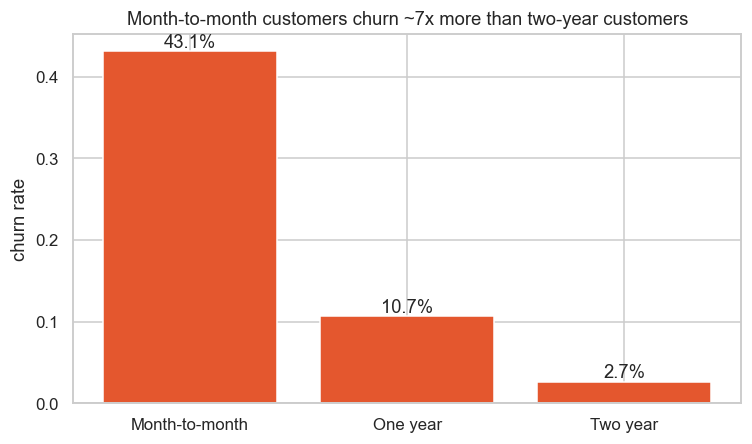

Churn               0      1
Contract                    
Month-to-month  0.569  0.431
One year        0.893  0.107
Two year        0.973  0.027


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ct = pd.crosstab(train["Contract"], train[lib.TARGET], normalize="index").sort_values(1, ascending=False)
ax.bar(ct.index, ct[1], color="#E4572E")
for i, v in enumerate(ct[1]):
    ax.text(i, v, f"{v:.1%}", ha="center", va="bottom")
ax.set_title("Month-to-month customers churn ~7x more than two-year customers")
ax.set_ylabel("churn rate")
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "eda_churn_by_contract.png", bbox_inches="tight")
plt.show()

print(pd.crosstab(train["Contract"], train[lib.TARGET], normalize="index").round(3))

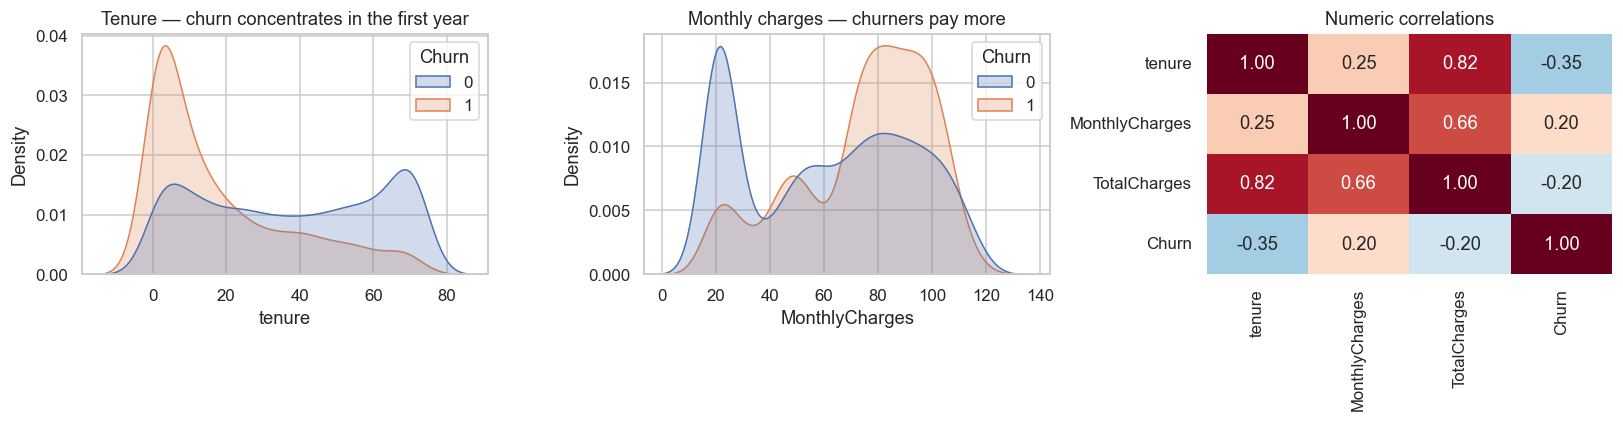

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.kdeplot(data=train, x="tenure", hue=lib.TARGET, fill=True, common_norm=False, ax=axes[0])
axes[0].set_title("Tenure — churn concentrates in the first year")

sns.kdeplot(data=train, x="MonthlyCharges", hue=lib.TARGET, fill=True, common_norm=False, ax=axes[1])
axes[1].set_title("Monthly charges — churners pay more")

num = train[["tenure", "MonthlyCharges", "TotalCharges", lib.TARGET]].corr()
sns.heatmap(num, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[2], cbar=False)
axes[2].set_title("Numeric correlations")

plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "eda_tenure_by_churn.png", bbox_inches="tight")
plt.show()

In [11]:
# Which categorical levels actually separate churners?
rows = []
for col in lib.MULTICLASS_FEATURES + lib.BINARY_FEATURES:
    for level, grp in train.groupby(col):
        rows.append({"feature": col, "level": str(level),
                     "n": len(grp), "churn_rate": grp[lib.TARGET].mean()})
levels = pd.DataFrame(rows)
levels[levels["n"] >= 100].sort_values("churn_rate", ascending=False).head(10)

,feature,level,n,churn_rate
29,PaymentMethod,Electronic check,1661,0.456352
24,Contract,Month-to-month,2710,0.430996
4,InternetService,Fiber optic,2155,0.421810
15,TechSupport,No,2413,0.419395
6,OnlineSecurity,No,2447,0.416837
9,OnlineBackup,No,2139,0.402057
12,DeviceProtection,No,2157,0.391748
21,StreamingMovies,No,1929,0.339036
40,PaperlessBilling,Yes,2929,0.338682
18,StreamingTV,No,1954,0.333675


### What the training data says

- **Contract length dominates.** Month-to-month churns around 43%; two-year is
  close to 3%. Nothing else comes near that spread.
- **The first year is the danger zone.** Churn density peaks at very low tenure
  and decays after.
- **Fiber optic customers churn more than DSL**, despite being the premium
  product — a service-quality or price-perception signal worth flagging to the
  business, not just to the model.
- **Electronic check** stands out among payment methods.
- `tenure` and `TotalCharges` correlate at ~0.83, which is mechanical
  (`TotalCharges ≈ tenure × MonthlyCharges`). Tree models will not care;
  it is a reason to keep an eye on the linear model's coefficients.

These four observations are what the engineered features below try to encode.

## 5. Feature engineering

Six features, each with a reason:

| Feature | Why |
|---|---|
| `tenure_group` | Churn risk changes in phases, not linearly. Buckets let a linear model capture that. |
| `avg_monthly_charge` | `TotalCharges / tenure`. Diverging from `MonthlyCharges` means the plan changed recently. |
| `charge_tenure_ratio` | Paying a lot without having stayed long. |
| `service_count` | More services = higher switching cost. Counted as "not No", so `InternetService` (DSL/Fiber/No) is included — an equals-"Yes" test would silently miss it. |
| `has_security_backup` | Both protection add-ons signals an engaged customer. |
| `high_value_short_tenure` | Above-median spend *and* under 12 months: the most expensive people to lose. |

The last one needs a median, and that is the catch. Computed on whatever data is
being scored, it is meaningless for a single API request. So it is learned in
`fit` — see `FeatureEngineer` in `pipeline_lib.py` — from the training fold only.
That one decision is what makes cross-validation honest here *and* keeps the API
consistent with training.

In [12]:
fe = FeatureEngineer().fit(X_train)
print(f"MonthlyCharges median learned from training data: ${fe.monthly_charges_median_:.2f}")

demo = fe.transform(X_train)
new_cols = ["tenure_group", "avg_monthly_charge", "service_count",
            "has_security_backup", "high_value_short_tenure", "charge_tenure_ratio"]
demo[new_cols].head()

MonthlyCharges median learned from training data: $70.35


,tenure_group,avg_monthly_charge,service_count,has_security_backup,high_value_short_tenure,charge_tenure_ratio
4926,61+,60.535484,5,0,0,0.970161
6795,49-60,83.653636,5,1,0,1.547273
2515,61+,114.594531,9,1,0,1.798437
2960,13-24,95.227273,6,0,0,4.579545
2599,61+,73.127778,7,1,0,1.013889


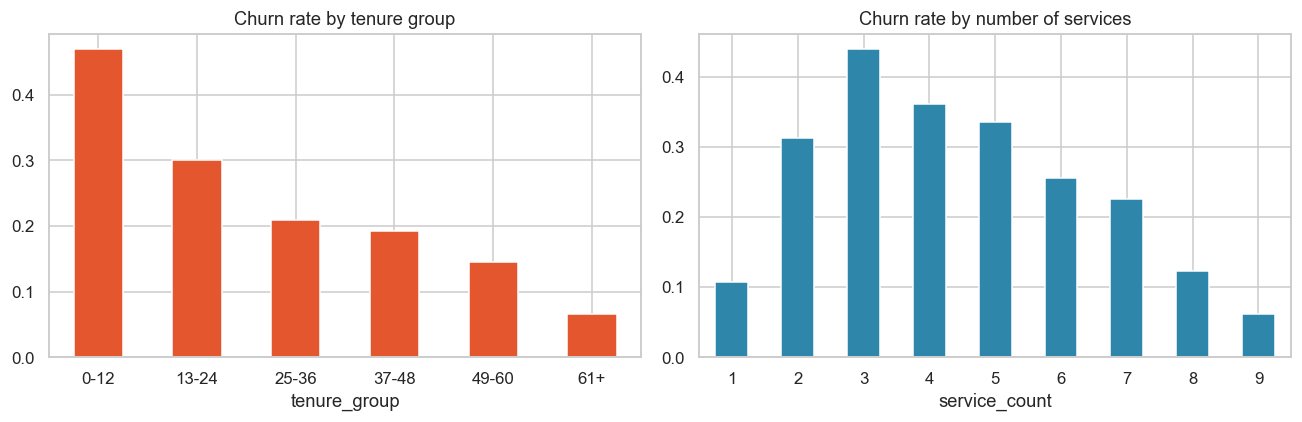

In [13]:
# Do the new features carry signal?
demo_y = y_train.loc[demo.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

demo.assign(churn=demo_y).groupby("tenure_group")["churn"].mean().plot(
    kind="bar", ax=axes[0], color="#E4572E")
axes[0].set_title("Churn rate by tenure group")
axes[0].tick_params(axis="x", rotation=0)

demo.assign(churn=demo_y).groupby("service_count")["churn"].mean().plot(
    kind="bar", ax=axes[1], color="#2E86AB")
axes[1].set_title("Churn rate by number of services")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 6. Preprocessing

One `ColumnTransformer`, four groups:

- **numeric** → median impute → standard scale
- **binary** (Yes/No, Male/Female) → `BinaryEncoder`, one column in, one out
- **multi-class** → one-hot, `drop=None`, `handle_unknown="ignore"`
- **0/1 flags** → passthrough, already encoded

`remainder="drop"` is a safety net: if a batch CSV arrives with extra columns,
they are ignored rather than crashing the request or sneaking into the model.

One choice worth defending: **`drop=None` rather than `drop="first"`.** Combined
with `handle_unknown="ignore"`, dropping the first level means an unseen category
at serving time encodes as all-zeros — which is exactly how the dropped baseline
level is encoded. Unknown values would silently be scored as the baseline. With
`drop=None`, unknowns get an all-zeros row that no real category shares. The
regularized models here do not need the collinearity drop anyway.

In [14]:
def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                              ("scaler", StandardScaler())]),
             lib.NUMERIC_FEATURES + lib.ENGINEERED_NUMERIC),
            ("bin", Pipeline([("encoder", BinaryEncoder())]), lib.BINARY_FEATURES),
            ("cat", Pipeline([("encoder", OneHotEncoder(
                drop=None, sparse_output=False, handle_unknown="ignore"))]),
             lib.MULTICLASS_FEATURES + lib.ENGINEERED_CATEGORICAL),
            ("flag", "passthrough", lib.FLAG_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

preprocessor = build_preprocessor()
_check = Pipeline([("features", FeatureEngineer()), ("preprocessor", clone(preprocessor))])
_check.fit(X_train, y_train)
feature_names = list(_check.named_steps["preprocessor"].get_feature_names_out())
print(f"{len(feature_names)} model-ready features")
print(feature_names[:8], "...")

51 model-ready features
['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'num__avg_monthly_charge', 'num__service_count', 'num__charge_tenure_ratio', 'bin__gender', 'bin__Partner'] ...


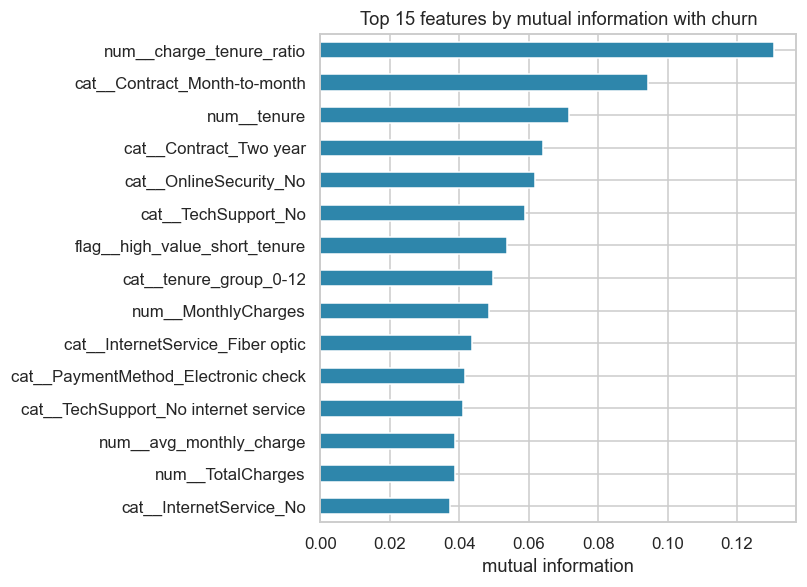

num__charge_tenure_ratio            0.1306
cat__Contract_Month-to-month        0.0942
num__tenure                         0.0716
cat__Contract_Two year              0.0642
cat__OnlineSecurity_No              0.0619
cat__TechSupport_No                 0.0589
flag__high_value_short_tenure       0.0537
cat__tenure_group_0-12              0.0496
num__MonthlyCharges                 0.0486
cat__InternetService_Fiber optic    0.0437
dtype: float64

In [15]:
# Mutual information: which features carry signal before any model sees them?
Xt = _check.transform(X_train)
mi = pd.Series(
    mutual_info_classif(Xt, y_train, random_state=RANDOM_STATE),
    index=feature_names,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
mi.head(15).iloc[::-1].plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_title("Top 15 features by mutual information with churn")
ax.set_xlabel("mutual information")
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "feature_selection_mi.png", bbox_inches="tight")
plt.show()
mi.head(10).round(4)

## 7. Model comparison

Three families, deliberately different in kind:

- **Logistic Regression** — the interpretable baseline. If it wins, ship it.
- **XGBoost** — depth-wise boosting with strong regularization.
- **LightGBM** — leaf-wise boosting, fast.

Every model gets the same pipeline (`FeatureEngineer → preprocessor →
classifier`) and the same tuning budget, so the comparison is about the model,
not about who got more attention. Imbalance is handled inside each model
(`class_weight`, `scale_pos_weight`, `is_unbalance`) rather than by resampling,
because at 27% positives the classes are skewed but not rare.

`RandomizedSearchCV` with 5-fold stratified CV, scoring ROC-AUC. Note
`n_jobs=1` on the boosters: the search already parallelizes across processes,
and nested thread pools oversubscribe the cores badly on Windows.

In [16]:
n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"class balance in training: {n_neg:,} stayed / {n_pos:,} churned  (ratio {scale_pos_weight:.2f})")

MODELS = {
    "Logistic Regression": (
        LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced", max_iter=1000),
        {
            "classifier__C": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
            "classifier__penalty": ["l2"],
            "classifier__solver": ["lbfgs", "liblinear"],
            "classifier__max_iter": [1000],
        },
    ),
    "XGBoost": (
        xgb.XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight,
                          eval_metric="logloss", verbosity=0, n_jobs=1),
        {
            "classifier__n_estimators": [100, 200, 300, 500],
            "classifier__max_depth": [3, 4, 5, 6, 7],
            "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
            "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "classifier__min_child_weight": [1, 3, 5, 7],
            "classifier__gamma": [0, 0.1, 0.2, 0.3],
            "classifier__reg_alpha": [0, 0.01, 0.1, 1.0],
            "classifier__reg_lambda": [0.5, 1.0, 1.5, 2.0],
        },
    ),
    "LightGBM": (
        lgb.LGBMClassifier(random_state=RANDOM_STATE, is_unbalance=True, verbosity=-1, n_jobs=1),
        {
            "classifier__n_estimators": [100, 200, 300, 500],
            "classifier__max_depth": [3, 5, 7, -1],
            "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "classifier__num_leaves": [15, 31, 50, 70],
            "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
            "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "classifier__min_child_samples": [5, 10, 20, 30],
            "classifier__reg_alpha": [0, 0.01, 0.1, 1.0],
            "classifier__reg_lambda": [0.5, 1.0, 1.5, 2.0],
        },
    ),
}

class balance in training: 3,623 stayed / 1,309 churned  (ratio 2.77)


In [17]:
import time

def n_combinations(grid):
    total = 1
    for v in grid.values():
        total *= len(v)
    return total

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fitted, search_results = {}, []

for name, (clf, grid) in MODELS.items():
    pipe = Pipeline([
        ("features", FeatureEngineer()),
        ("preprocessor", clone(preprocessor)),
        ("classifier", clf),
    ])
    search = RandomizedSearchCV(
        pipe, grid,
        n_iter=min(50, n_combinations(grid)),
        cv=cv, scoring="roc_auc",
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0, return_train_score=True,
    )
    t0 = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - t0

    fitted[name] = search.best_estimator_
    search_results.append({
        "model": name,
        "cv_roc_auc": search.best_score_,
        "train_roc_auc": search.cv_results_["mean_train_score"][search.best_index_],
        "fit_seconds": round(elapsed, 1),
    })
    print(f"{name:22} CV ROC-AUC {search.best_score_:.4f}   ({elapsed:5.1f}s)")

pd.DataFrame(search_results).set_index("model").round(4)

Logistic Regression    CV ROC-AUC 0.8488   (  6.0s)


XGBoost                CV ROC-AUC 0.8505   ( 14.6s)


LightGBM               CV ROC-AUC 0.8491   ( 11.7s)


,cv_roc_auc,train_roc_auc,fit_seconds
model,,,
Logistic Regression,0.8488,0.8546,6.0
XGBoost,0.8505,0.8736,14.6
LightGBM,0.8491,0.8660,11.7


## 8. Choose the champion — on validation

Selecting on the test set would make the final number a best-of-three, which is
optimistic by construction. The validation set is what selection is for.

In [18]:
def score_split(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y, proba),
        "pr_auc": average_precision_score(y, proba),
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
    }

comparison = pd.DataFrame({
    name: {**{f"val_{k}": v for k, v in score_split(m, X_val, y_val).items()},
           **{f"test_{k}": v for k, v in score_split(m, X_test, y_test).items()}}
    for name, m in fitted.items()
}).T

comparison["overfit_gap"] = comparison["val_roc_auc"] - comparison["test_roc_auc"]
comparison = comparison.sort_values("val_roc_auc", ascending=False)

best_name = comparison.index[0]
best_model = fitted[best_name]
print(f"champion on validation ROC-AUC: {best_name}\n")
comparison[["val_roc_auc", "test_roc_auc", "val_recall", "val_precision", "val_f1"]].round(4)

champion on validation ROC-AUC: Logistic Regression


,val_roc_auc,test_roc_auc,val_recall,val_precision,val_f1
Logistic Regression,0.8367,0.8538,0.7643,0.5232,0.6212
XGBoost,0.8356,0.8555,0.7929,0.5224,0.6298
LightGBM,0.8339,0.8548,0.7857,0.5164,0.6232


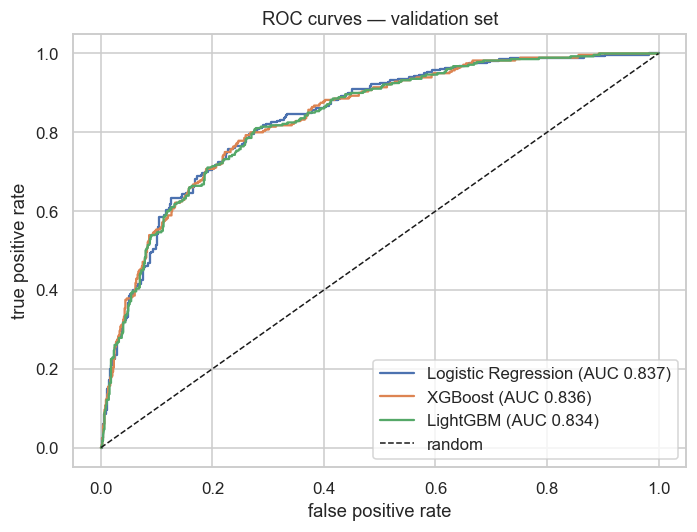

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for name, m in fitted.items():
    proba = m.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_val, proba):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set(xlabel="false positive rate", ylabel="true positive rate",
       title="ROC curves — validation set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "roc_curves_comparison.png", bbox_inches="tight")
plt.show()

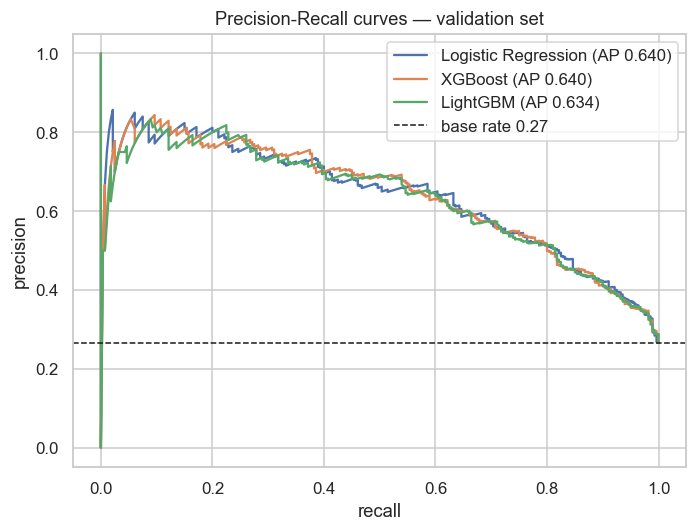

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for name, m in fitted.items():
    proba = m.predict_proba(X_val)[:, 1]
    prec_c, rec_c, _ = precision_recall_curve(y_val, proba)
    ax.plot(rec_c, prec_c, label=f"{name} (AP {average_precision_score(y_val, proba):.3f})")
ax.axhline(y_val.mean(), color="k", ls="--", lw=1, label=f"base rate {y_val.mean():.2f}")
ax.set(xlabel="recall", ylabel="precision", title="Precision-Recall curves — validation set")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "pr_curves_comparison.png", bbox_inches="tight")
plt.show()

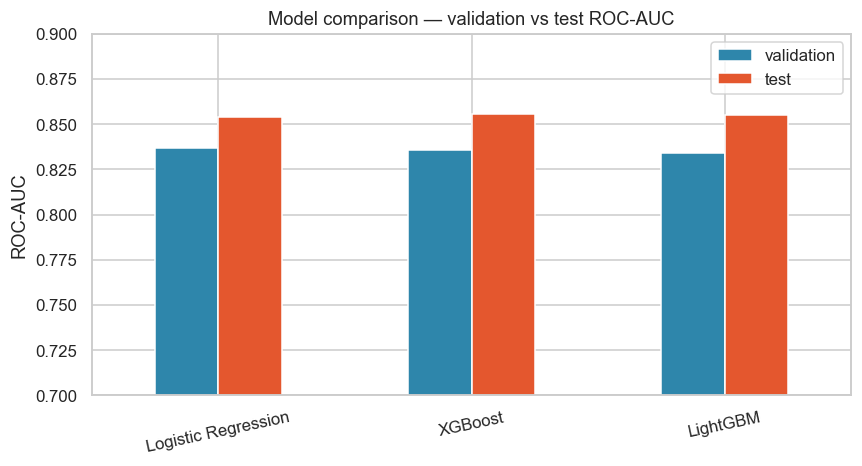

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.4))
comparison[["val_roc_auc", "test_roc_auc"]].plot(kind="bar", ax=ax, color=["#2E86AB", "#E4572E"])
ax.set_title("Model comparison — validation vs test ROC-AUC")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.7, 0.9)
ax.tick_params(axis="x", rotation=12)
ax.legend(["validation", "test"])
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "model_comparison_bar.png", bbox_inches="tight")
plt.show()

### Reading the comparison

The three models land within a couple of thousandths of each other on
validation AUC. That is the honest result: on 7,000 rows of tabular data with
strong, mostly linear signal, gradient boosting has nothing extra to find.

When the numbers tie, the tiebreaker is everything else — the linear model
trains in seconds, its coefficients are directly interpretable, it has a smaller
train/validation gap, and it is far easier to defend to a stakeholder. So the
champion here is not a compromise; it is the right pick.

## 9. The decision threshold

An AUC does not tell the retention team who to call. That needs a cutoff, and
0.5 is just a default nobody chose.

I tune it on **validation** by maximizing F1, then save it alongside the model.
The API reads it from the metadata instead of hardcoding 0.5, so the decision
boundary is a property of the model artifact rather than a magic number in the
serving code.

(If the business handed me a real cost ratio — what a retention call costs
versus what a lost customer costs — I would optimize expected cost directly
instead of F1. F1 is the neutral choice absent that number.)

tuned threshold: 0.6691   (default would be 0.5000)
at that cutoff on validation — F1 0.6390, precision 0.6460, recall 0.6321


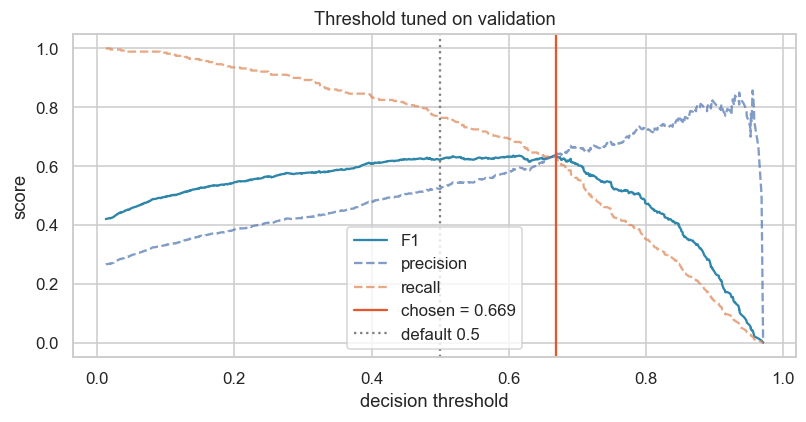

In [22]:
val_proba = best_model.predict_proba(X_val)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_val, val_proba)
prec, rec = prec[:-1], rec[:-1]
denom = prec + rec
f1s = np.divide(2 * prec * rec, denom, out=np.zeros_like(denom), where=denom > 0)
best_idx = int(np.argmax(f1s))
threshold = float(thresholds[best_idx])

print(f"tuned threshold: {threshold:.4f}   (default would be 0.5000)")
print(f"at that cutoff on validation — F1 {f1s[best_idx]:.4f}, "
      f"precision {prec[best_idx]:.4f}, recall {rec[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(thresholds, f1s, label="F1", color="#2E86AB")
ax.plot(thresholds, prec, label="precision", ls="--", alpha=.7)
ax.plot(thresholds, rec, label="recall", ls="--", alpha=.7)
ax.axvline(threshold, color="#E4572E", label=f"chosen = {threshold:.3f}")
ax.axvline(0.5, color="grey", ls=":", label="default 0.5")
ax.set(xlabel="decision threshold", ylabel="score", title="Threshold tuned on validation")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Opening the test set

First and only time. Everything above — model choice, hyperparameters,
threshold — was decided without it.

In [23]:
test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= threshold).astype(int)

test_metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred),
}
test_auc = roc_auc_score(y_test, test_proba)
val_auc = roc_auc_score(y_val, val_proba)

print(f"{best_name} on the held-out test set")
print(f"  ROC-AUC          {test_auc:.4f}   (validation was {val_auc:.4f})")
for k, v in test_metrics.items():
    print(f"  {k:<16} {v:.4f}")
print()
print(classification_report(y_test, test_pred, target_names=["stayed", "churned"]))

Logistic Regression on the held-out test set
  ROC-AUC          0.8538   (validation was 0.8367)
  accuracy         0.7956
  precision        0.6127
  recall           0.6214
  f1               0.6170

              precision    recall  f1-score   support

      stayed       0.86      0.86      0.86       777
     churned       0.61      0.62      0.62       280

    accuracy                           0.80      1057
   macro avg       0.74      0.74      0.74      1057
weighted avg       0.80      0.80      0.80      1057



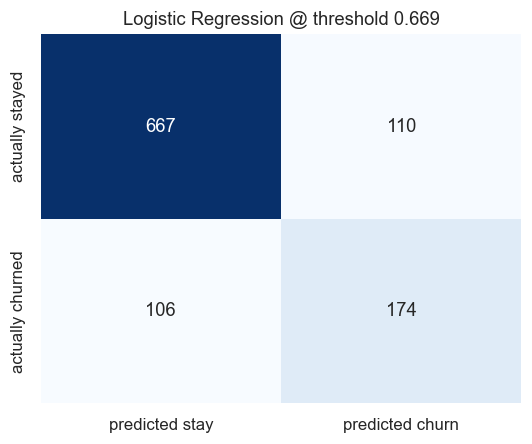

caught 174 of 280 churners (62.1%)
called 284 customers, 110 of them unnecessarily


In [24]:
cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["predicted stay", "predicted churn"],
            yticklabels=["actually stayed", "actually churned"], ax=ax)
ax.set_title(f"{best_name} @ threshold {threshold:.3f}")
plt.tight_layout()
slug = best_name.lower().replace(" ", "_")
plt.savefig(lib.FIGURES_DIR / f"confusion_matrix_{slug}_test.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"caught {tp} of {tp + fn} churners ({tp/(tp+fn):.1%})")
print(f"called {tp + fp} customers, {fp} of them unnecessarily")

## 11. Why the model says what it says

SHAP values, on the validation set. `LinearExplainer` for a linear champion,
`TreeExplainer` for a booster — the model-agnostic `KernelExplainer` is
exponentially slower and unnecessary when an exact explainer exists.

In [25]:
import shap

pre = best_model.named_steps["preprocessor"]
clf = best_model.named_steps["classifier"]
X_val_t = best_model.named_steps["features"].transform(X_val)
X_val_enc = pd.DataFrame(pre.transform(X_val_t), columns=feature_names, index=X_val.index)

if isinstance(clf, LogisticRegression):
    explainer = shap.LinearExplainer(clf, X_val_enc)
else:
    explainer = shap.TreeExplainer(clf)

shap_values = explainer.shap_values(X_val_enc)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[..., 1]

print(f"SHAP matrix: {shap_values.shape}")

C:\Users\pc\Downloads\data\churn\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP matrix: (1054, 51)


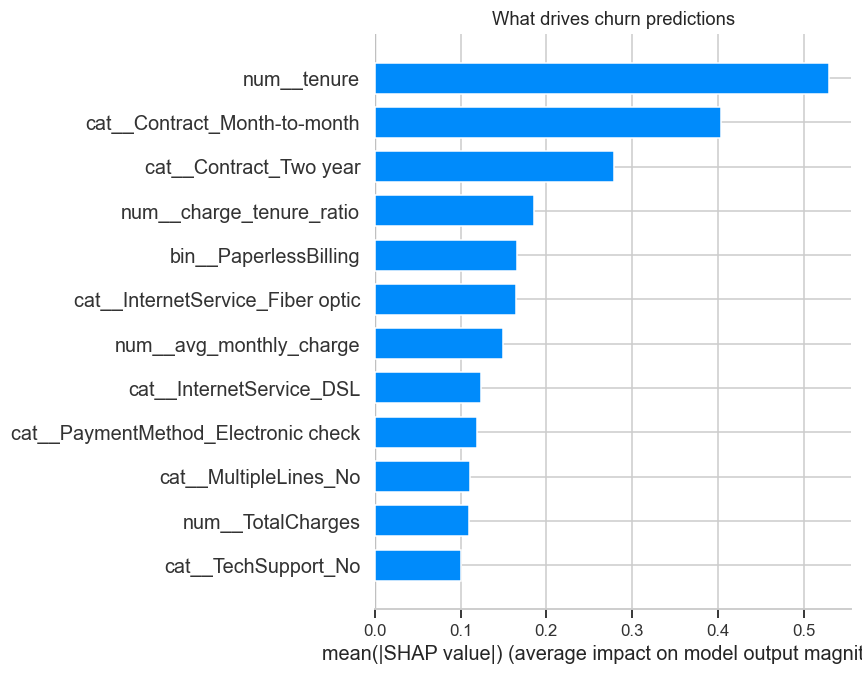

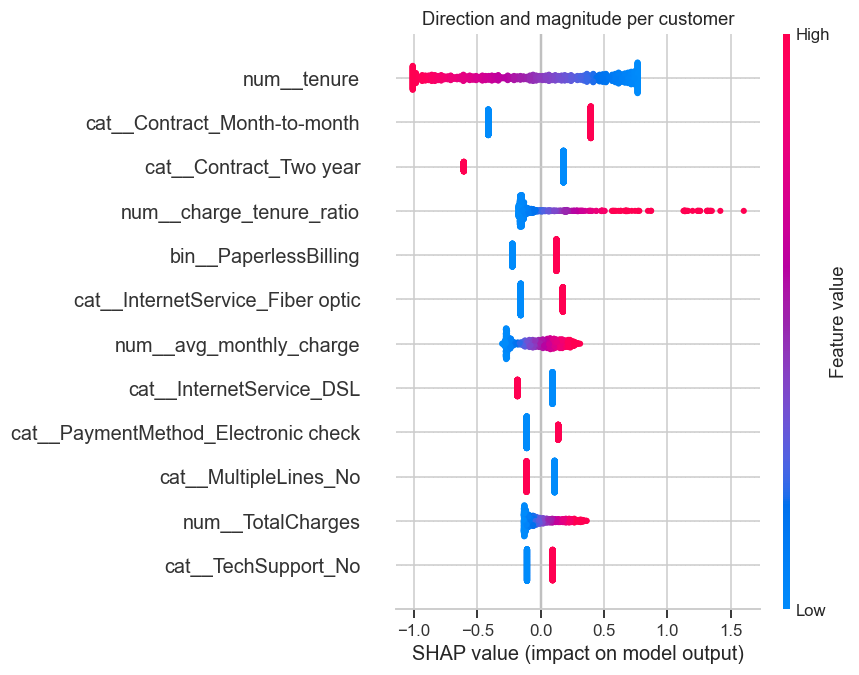

In [26]:
shap.summary_plot(shap_values, X_val_enc, plot_type="bar", max_display=12, show=False)
plt.title("What drives churn predictions")
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "shap_bar.png", bbox_inches="tight")
plt.show()

shap.summary_plot(shap_values, X_val_enc, max_display=12, show=False)
plt.title("Direction and magnitude per customer")
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "shap_summary.png", bbox_inches="tight")
plt.show()

In [27]:
importance = (pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
              .sort_values(ascending=False))
importance.head(10).round(4)

num__tenure                            0.5291
cat__Contract_Month-to-month           0.4035
cat__Contract_Two year                 0.2794
num__charge_tenure_ratio               0.1851
bin__PaperlessBilling                  0.1661
cat__InternetService_Fiber optic       0.1648
num__avg_monthly_charge                0.1490
cat__InternetService_DSL               0.1241
cat__PaymentMethod_Electronic check    0.1187
cat__MultipleLines_No                  0.1109
dtype: float64

The drivers line up with the EDA and with how the business already thinks:
tenure and month-to-month contracts dominate, fiber optic pushes risk up, and
the engineered `charge_tenure_ratio` earns its place near the top. A model whose
explanation contradicted the domain would be a reason to go back, not to ship.

## 12. Save what serving needs

Three artifacts:

- **`final_pipeline.joblib`** — the whole pipeline, feature engineering included,
  so the API hands it a raw customer record and gets a probability back. No
  feature code duplicated in the serving layer means no train/serve skew.
- **`feature_names.joblib`** — for explanations.
- **`model_metadata.json`** — champion name, the tuned threshold, and the
  metrics. The API reads the threshold from here.

In [28]:
# The splits themselves, so anyone re-running this notebook can reproduce the
# exact evaluation - and so the Streamlit app has a background sample for SHAP.
X_train.assign(**{lib.TARGET: y_train}).to_csv(lib.PROCESSED_TRAIN_FILE, index=False)
X_val.assign(**{lib.TARGET: y_val}).to_csv(lib.PROCESSED_VAL_FILE, index=False)
X_test.assign(**{lib.TARGET: y_test}).to_csv(lib.PROCESSED_TEST_FILE, index=False)

joblib.dump(best_model, lib.FINAL_PIPELINE_PATH)
joblib.dump(feature_names, lib.FEATURE_NAMES_PATH)

metadata = {
    "best_model": best_name,
    "decision_threshold": round(threshold, 4),
    "val_roc_auc": round(float(val_auc), 4),
    "test_roc_auc": round(float(test_auc), 4),
    "test_metrics_at_threshold": {k: round(float(v), 4) for k, v in test_metrics.items()},
    "trained_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "n_training_rows": int(len(X_train)),
}
lib.MODEL_METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

comparison.round(4).to_csv(lib.REPORTS_DIR / "model_comparison.csv")

print(json.dumps(metadata, indent=2))
print(f"\nsaved -> {lib.FINAL_PIPELINE_PATH.name}, {lib.FEATURE_NAMES_PATH.name}, "
      f"{lib.MODEL_METADATA_PATH.name}")

{
  "best_model": "Logistic Regression",
  "decision_threshold": 0.6691,
  "val_roc_auc": 0.8367,
  "test_roc_auc": 0.8538,
  "test_metrics_at_threshold": {
    "accuracy": 0.7956,
    "precision": 0.6127,
    "recall": 0.6214,
    "f1": 0.617
  },
  "trained_at_utc": "2026-08-01T20:01:30.575293+00:00",
  "n_training_rows": 4932
}

saved -> final_pipeline.joblib, feature_names.joblib, model_metadata.json


In [29]:
# Sanity check: reload the artifact and score one raw customer, the way the API will
reloaded = joblib.load(lib.FINAL_PIPELINE_PATH)
one_customer = X_test.iloc[[0]]
p = float(reloaded.predict_proba(one_customer)[0, 1])
print(f"reloaded pipeline scores a raw record: p(churn) = {p:.4f} "
      f"-> {'CHURN' if p >= threshold else 'stay'} at threshold {threshold:.3f}")
assert abs(p - float(best_model.predict_proba(one_customer)[0, 1])) < 1e-12
print("reloaded model matches the in-memory model exactly")

reloaded pipeline scores a raw record: p(churn) = 0.1521 -> stay at threshold 0.669
reloaded model matches the in-memory model exactly


## What I would do next

- **Get the real cost ratio.** F1 is a placeholder for a business number nobody
  has given me yet. Retention call cost versus customer lifetime value would let
  me optimize expected profit instead, and would probably move the threshold.
- **Watch fiber optic.** The churn gap versus DSL looks like a product problem,
  not a modeling one. Worth a conversation before another modeling round.
- **Monitor drift.** Contract mix and pricing move; the tuned threshold should
  be re-checked on fresh data, not treated as permanent.
- **Uplift, eventually.** This model ranks who is *likely to leave*, not who is
  *persuadable*. Those differ, and the second is what a retention budget really
  wants.